# 基于 Embedding + LSTM 的 IMDB 情感分类

本 Notebook 演示如何使用 PyTorch 构建一个基于词嵌入（Embedding）和长短期记忆网络（LSTM）的文本情感分类模型，完成 IMDB 电影评论的正负情感二分类任务。

**主要内容：**
1. 加载 IMDB 数据集：通过 HuggingFace `datasets` 加载原始文本并构建词表
2. 构造 word2idx / idx2word：文本清洗、分词与词典映射
3. 分析数据长度分布：确定截断/填充的最大序列长度
4. Tokenizer：实现编码与解码
5. 数据集与 DataLoader：封装批训练流水线
6. 定义模型：实现单向/双向、单层/多层 LSTM 分类器
7. 训练：实现训练循环，集成 TensorBoard 可视化、模型保存与早停策略
8. 结果：绘制学习曲线并评估最终模型性能

In [182]:
import matplotlib as mpl           # Matplotlib 主模块，用于绘图配置
import matplotlib.pyplot as plt     # pyplot：提供类似 MATLAB 的绘图接口
%matplotlib inline
 # Jupyter 魔法命令：将图表直接渲染在 Notebook 中
import numpy as np                  # NumPy：高性能数值计算库
import sklearn                      # Scikit-learn：机器学习工具库（用于 accuracy_score 等）
import pandas as pd                 # Pandas：数据处理与分析库
import os                           # os 模块：操作系统接口（文件/目录操作）
import sys                          # sys 模块：访问 Python 解释器相关信息
import time                         # time 模块：时间相关函数
from tqdm import tqdm          # tqdm：进度条工具，auto 模式自动适配终端/Jupyter
import torch                        # PyTorch 核心模块
import torch.nn as nn               # torch.nn：神经网络模块（层、损失函数等）
import torch.nn.functional as F     # torch.nn.functional：无参数的函数式 API（激活函数、损失等）

# 打印 Python 版本信息
print(sys.version_info)
# 打印各依赖库的版本，便于复现实验环境
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

# 优先使用 GPU（cuda:0），若不可用则退回 CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)  # 打印当前使用的设备

seed = 42  # 随机种子，用于保证实验可复现性


sys.version_info(major=3, minor=14, micro=5, releaselevel='final', serial=0)
matplotlib 3.10.9
numpy 2.4.6
pandas 3.0.3
sklearn 1.9.0
torch 2.12.0+cu132
cuda:0


## 一、加载 IMDB 数据集

本节通过 HuggingFace `datasets` 库加载 [stanfordnlp/imdb](https://huggingface.co/datasets/stanfordnlp/imdb) 数据集。该数据集包含 **50 000** 条英文电影评论，已划分为训练集 25 000 条、测试集 25 000 条；每条样本包含原始文本 `text` 与情感标签 `label`（0 = 负面，1 = 正面）。与 Keras 预处理后版本不同，此处保留**原始字符串**，便于后续自定义分词与词典构建。

### 1.1 从 HuggingFace 下载并缓存数据集

使用 `load_dataset` 接口自动下载数据到本地 `cache_dir`，避免重复联网。返回值为 `DatasetDict` 类型，可通过键名 `'train'`、`'test'` 访问各子集。

In [183]:
from datasets import load_dataset  # HuggingFace datasets 库：提供 load_dataset 统一数据加载接口

cache_dir = 'data/imdb'  # str：本地缓存目录路径，下载后的 Arrow 文件将保存在此

if not os.path.exists(cache_dir):  # os.path.exists(path) -> bool：判断目录是否已存在
    os.makedirs(cache_dir)  # os.makedirs(path)：递归创建目录（含父目录），已存在时不报错

# load_dataset(name, cache_dir) -> DatasetDict
#   name: 数据集标识符，'stanfordnlp/imdb' 为 Stanford NLP 发布的 IMDB 影评数据集
#   cache_dir: 指定缓存位置，第二次运行将直接读取本地文件，无需重新下载
dataset = load_dataset('stanfordnlp/imdb', cache_dir=cache_dir)

print(type(dataset))  # 预期输出 <class 'datasets.dataset_dict.DatasetDict'>，类似字典，键为 split 名
print(type(dataset['train']['text']))  # 预期输出 Column 类型，存储该列所有文本，支持索引访问

<class 'datasets.dataset_dict.DatasetDict'>
<class 'datasets.arrow_dataset.Column'>


### 1.2 提取训练集与测试集的文本和标签

将 `DatasetDict` 中各 split 的 `text`、`label` 列转为 NumPy 一维数组，便于后续向量化处理与批训练。`label` 为整数 0（负面）或 1（正面）。

In [184]:
# np.array(iterable) -> ndarray：将 Column / 列表转为 NumPy 数组，dtype 由元素类型自动推断
train_texts = np.array(dataset['train']['text'])    # shape=(25000,)，元素为 str，训练集评论原文
train_labels = np.array(dataset['train']['label'])  # shape=(25000,)，元素为 int64，取值 0 或 1
test_texts = np.array(dataset['test']['text'])      # shape=(25000,)，测试集评论原文
test_labels = np.array(dataset['test']['label'])    # shape=(25000,)，测试集情感标签

## 二、构造 word2idx 和 idx2word

在自然语言处理中，模型只能处理数值输入，因此需要将单词映射为整数索引。本节基于**训练集**统计词频、构建有限大小的词典，并预留特殊符号：`<PAD>`（填充）、`<OOV>`（未登录词）、`<BOS>`（句首）、`<EOS>`（句尾）。测试集中未出现在训练词典里的词将统一映射为 `<OOV>`。

### 2.1 文本清洗与分词

对训练文本做简单规范化：将标点替换为空格、合并连续空白，再按空格切分为词列表。仅在训练集上统计词频，避免测试集信息泄露。

In [185]:
from collections import Counter  # Counter：可哈希元素的可变映射，专门用于词频统计；most_common(n) 按频率降序返回最高频 n 项

import re  # re：正则表达式模块，用于复杂字符串模式匹配与替换

def clean_text(text):
    """
    对单条评论做轻量文本清洗。

    参数:
        text (str): 原始电影评论字符串。

    返回:
        str: 清洗后的文本，首尾无多余空白，词与词之间以单个空格分隔。
    """
    text = text.replace(',', ' ').replace('.', ' ')  # 将逗号、句号替换为空格，弱化标点对分词的影响
    text = re.sub(r'\s+', ' ', text)  # re.sub(pattern, repl, s)：将连续空白（空格/换行/制表符）合并为一个空格
    return text.strip()  # str.strip()：去除首尾空白字符，返回新字符串

# 列表推导式：对 train_texts 中每条评论调用 clean_text，再封装为 NumPy 数组
train_texts = np.array([clean_text(t) for t in train_texts])  # shape 仍为 (25000,)，元素为清洗后的 str
test_texts= np.array([clean_text(t) for t in test_texts])   #测试集数据也清洗

all_words = []  # list[str]：存放训练集全部分词结果，用于后续统计词频
for text in train_texts:  # 遍历每条清洗后的评论
    all_words.extend(text.split())  # str.split()：默认按任意空白切分，返回 list[str]；extend 将词追加到 all_words

word_counts = Counter(all_words)  # Counter(all_words) -> Counter：键为单词，值为出现次数

### 2.2 构建 word2idx 与 idx2word 映射

选取词频最高的若干词填入词典（索引从 4 起），并建立反向映射 `idx2word`，便于将整数索引还原为可读单词。超出词典容量的词在编码阶段将映射为 `<OOV>`（索引 1）。

In [186]:
max_vocab_size = 20000  # int：词典总容量上限（含 4 个特殊符号），Embedding 层 num_embeddings 将与此一致

# dict[str, int]：词 -> 索引；索引 0~3 预留给特殊 token，普通词从 4 开始编号
word2idx = {'<PAD>': 0, '<OOV>': 1, '<BOS>': 2, '<EOS>': 3}

# Counter.most_common(n) -> list[tuple[str, int]]：返回频率最高的 n 个 (词, 次数) 元组
# 排序规则：按词频降序（出现次数多的在前，少的在后），频率相同时按首次出现顺序排列
most_common_words = word_counts.most_common(max_vocab_size - 4)  # 预留 4 个位置给特殊符号；列表首项为最高频词

start = 4  # int：普通词汇索引起始值（0~3 已被特殊符号占用）
for idx, (word, count) in enumerate(most_common_words, start=start):
    # enumerate(iterable, start)：同时产出索引 idx 与元素 (word, count)
    # 因 most_common 为降序，idx=4 对应最高频词，idx 越大对应词频越低
    word2idx[word] = idx  # 将高频词写入正向词典，idx 从 4 递增到 max_vocab_size - 1

print(f"词典大小: {len(word2idx)}")  # len(dict) -> int：当前词典中的条目总数

# 字典推导式：由 word2idx 反转得到 idx2word，键为 int 索引，值为 str 单词
idx2word = {idx: word for word, idx in word2idx.items()}  # dict[int, str]

vocab_size = len(word2idx)  # int：词典条目总数，供后续 Embedding 层 num_embeddings 使用

for i in range(10):  # 打印前 10 个索引对应的词，验证特殊符号与普通词编号是否正确
    print(f"{i}: {idx2word[i]}")  # 预期 0~3 为 <PAD>/<OOV>/<BOS>/<EOS>，4 起为高频实词

词典大小: 20000
0: <PAD>
1: <OOV>
2: <BOS>
3: <EOS>
4: the
5: a
6: and
7: of
8: to
9: is


## 三、分析数据长度分布

统计训练集中各评论的单词数（序列长度），可视化其分布，并确定截断/填充的最大长度 `MAX_LENGTH`。

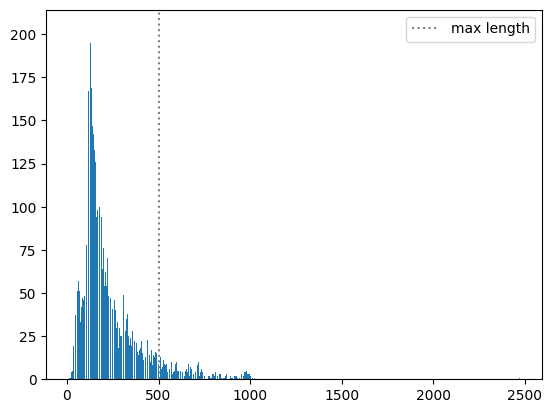

In [187]:
# 选择合适的最大序列长度（max_length）
length_collect = {}  # 用字典存储 {序列长度: 出现次数} 的频率统计

# 遍历训练集中每条评论，统计其长度出现次数
for text in train_texts:
    length = len(text.split())                                       # 获取当前评论的单词数（序列长度）
    length_collect[length] = length_collect.get(length, 0) + 1  # 累计该长度出现次数

# 设置最大序列长度——超过此长度的评论将被截断，短于此长度的将被填充（Padding）
MAX_LENGTH = 500

# 绘制各长度频率的柱状图，横轴为序列长度，纵轴为出现次数
plt.bar(length_collect.keys(), length_collect.values())
# 在 MAX_LENGTH=500 处绘制竖虚线，直观展示截断位置（绝大多数评论长度在 500 以内）
plt.axvline(MAX_LENGTH, label="max length", c="gray", ls=":")
plt.legend()  # 显示图例
plt.show()    # 渲染图表

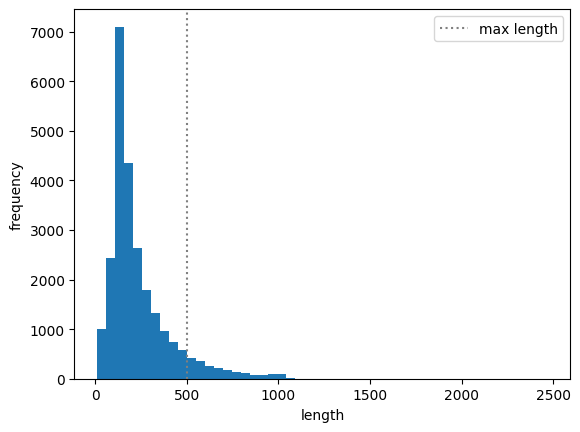

In [188]:
# 用直方图更直观地展示句子长度分布（bins=50 将范围分为 50 个区间）
# 列表推导式：提取每条评论的单词数，生成长度列表
length_list = [len(text.split()) for text in train_texts]  # List[int]，每个元素为对应评论的长度

# 绘制长度分布直方图
plt.hist(length_list, bins=50)       # bins=50：将长度范围均分为 50 个区间
plt.xlabel("length")                 # 横轴：序列长度（单词数）
plt.ylabel("frequency")              # 纵轴：出现频次
plt.axvline(500, label="max length", c="gray", ls=":")  # 在 500 处画竖虚线标注截断点
plt.legend()                         # 显示图例
plt.show()                           # 渲染图表

### 3.1 查看前 10 条样本的长度

In [189]:
# 查看前 10 条训练样本的序列长度
# 返回值：List[int]，例如 [292, 214, 96, ...]
# 可以看到不同评论的长度差异很大，因此需要 Padding 将其统一到相同长度
length_list[0:10]

[292, 214, 96, 121, 325, 123, 114, 303, 486, 224]

In [190]:
# 构造一个用于演示 Tokenizer 功能的原始文本列表（批量输入格式）
# 每个元素都是 List[str]（分词后的单词列表），模拟真实 NLP 管道中的批次数据
raw_text = [
    "hello world".split(),               # 样本 1：["hello", "world"]
    "tokenize text datas with batch".split(),  # 样本 2：5 个单词
    "this is a test".split()             # 样本 3：4 个单词
]
raw_text  # 打印查看批次原始文本结构

[['hello', 'world'],
 ['tokenize', 'text', 'datas', 'with', 'batch'],
 ['this', 'is', 'a', 'test']]

## 四、Tokenizer

封装一个 `Tokenizer` 类，实现 **编码（Encode）** 和 **解码（Decode）** 两大核心功能：
- **Encode**：将原始文本批次转换为填充后的整数 id 张量
- **Decode**：将整数 id 序列还原为可读文本

In [191]:
class Tokenizer:
    def __init__(self, word2idx, idx2word, max_length=500,
                 pad_idx=0, bos_idx=2, eos_idx=3, unk_idx=1,
                 truncate_mode='adaptive'):
        """
        初始化 Tokenizer（文本编解码器）
        参数：
            word2idx       (Dict[str,int]): 单词 → id 映射字典
            idx2word       (Dict[int,str]): id → 单词 映射字典
            max_length     (int):           序列最大长度，超出则按 truncate_mode 处理，默认 500
            pad_idx        (int):           填充 token 的 id，默认 0
            bos_idx        (int):           句子起始 token 的 id，默认 2
            eos_idx        (int):           句子结束 token 的 id，默认 3
            unk_idx        (int):           未知词 token 的 id，默认 1
            truncate_mode  (str):           超长序列截断策略，默认 'adaptive'
                - 'adaptive'：自适应步长，在全文上等间隔采样 max_length 个 token
                - 'head'    ：保留句首，丢弃末尾（index[:max_length]）
                - 'tail'    ：保留句尾，丢弃开头（index[-max_length:]）
        """
        self.word2idx       = word2idx        # 单词 → id 字典，用于编码
        self.idx2word       = idx2word        # id → 单词 字典，用于解码
        self.max_length     = max_length      # 序列截断/填充的最大长度
        self.pad_idx        = pad_idx         # 填充符 id
        self.bos_idx        = bos_idx         # 句子起始符 id
        self.eos_idx        = eos_idx         # 句子结束符 id
        self.unk_idx        = unk_idx         # 未知词 id
        valid_modes = ('adaptive', 'head', 'tail')  # 允许的截断策略枚举
        if truncate_mode not in valid_modes:
            raise ValueError(f"truncate_mode 必须是 {valid_modes} 之一，当前为 {truncate_mode!r}")
        self.truncate_mode  = truncate_mode   # str：超长序列截断策略

    def _truncate_to_max_length(self, index, max_length):
        """
        将超长 id 序列压缩到 max_length（仅当 len(index) >= max_length 时调用）
        参数：
            index      (List[int]): 单条样本的 token id 列表
            max_length (int):       目标序列长度
        返回：
            List[int]，长度恒为 max_length
        """
        if self.truncate_mode == 'head':
            return index[:max_length]  # 保留句首 max_length 个 token，丢弃末尾
        if self.truncate_mode == 'tail':
            return index[-max_length:]  # 保留句尾 max_length 个 token，丢弃开头
        # adaptive：步长 step ≈ len(index) / max_length，在 [0, len-1] 上等间隔采样
        positions = np.linspace(0, len(index) - 1, max_length, dtype=int)  # ndarray[int]，形状 (max_length,)
        return [index[i] for i in positions]  # List[int]，兼顾首尾与中间信息

    def encode(self, text_list, padding_first=False):
        """
        将文本列表批量编码为整数 id 张量
        参数：
            text_list      (List[List[str]]): 每条文本已拆分为单词列表
            padding_first  (bool):           True 时前缀填充（PAD 在序列头部，避免 RNN 递推时句末语义被 PAD 稀释）；
                                             False 时后缀填充（PAD 在序列尾部，适合池化/CNN 等不依赖最后时间步的模型）
        返回：
            torch.Tensor，形状 (batch_size, seq_len)，dtype=torch.long
        """
        # 动态确定本批次的序列长度（取最长句，但不超过 max_length）
        max_length = min(self.max_length, max(
            [len(text) for text in text_list]))

        indices = []
        for text in text_list:
            index = [self.word2idx.get(word, self.unk_idx) for word in text]  # 单词 → id
            if len(index) < max_length:
                pad_len = max_length - len(index)  # int：需要补充的 PAD 个数
                if padding_first:
                    index = [self.pad_idx] * pad_len + index  # 前缀填充：PAD 在前，有效词靠后，避免句末语义被稀释
                else:
                    index = index + [self.pad_idx] * pad_len  # 后缀填充：PAD 追加在序列尾部
            else:
                index = self._truncate_to_max_length(index, max_length)  # 按 truncate_mode 处理超长序列
            indices.append(index)
        return torch.tensor(indices)  # List[List[int]] → 2D Tensor

    def decode(self, indices_list, remove_pad=True, split=False):
        """
        将整数 id 序列还原为文本
        参数：
            indices_list (List[List[int]]): 每条样本的 id 序列
            remove_pad   (bool): 是否跳过 PAD ，默认 True（前缀 PAD 跳过，后缀 PAD 遇则停止）
            split        (bool): False 返回字符串；True 返回单词列表
        返回：List[str] 或 List[List[str]]
        """
        text_list = []
        for indices in indices_list:
            text = []
            for index in indices:
                word = self.idx2word.get(index, "<UNK>")  # id → 单词
                if remove_pad and word == "<PAD>":
                    if text:  # 已有有效词后遇到 PAD，说明是后缀填充，停止解码
                        break
                    continue  # 跳过前缀 PAD
                text.append(word)
            text_list.append(" ".join(text) if not split else text)
        return text_list


# 实例化 Tokenizer；truncate_mode 可选 'adaptive'（默认）、'head'、'tail'
tokenizer = Tokenizer(word2idx=word2idx, idx2word=idx2word, truncate_mode='adaptive')

# 测试示例文本的编码效果（RNN 使用 padding_first=True，前缀填充以保留句末有效语义）
raw_text = ["hello world".split(),
            "tokenize text datas with batch".split(),
            "this is a test".split()]
indices = tokenizer.encode(raw_text, padding_first=True)  # encode 支持批量处理与前缀填充

print("raw text:")  # 打印原始文本
for raw in raw_text:
    print(raw)
print("\n")
print("indices:")   # 打印编码后的 id 张量
for index in indices:
    print(index)
print("\n")


raw text:
['hello', 'world']
['tokenize', 'text', 'datas', 'with', 'batch']
['this', 'is', 'a', 'test']


indices:
tensor([    0,     0,     0, 14989,   229])
tensor([   1, 3166,    1,   19,    1])
tensor([   0,   14,    9,    5, 2429])




In [192]:
# 演示 decode：将编码后的 id 张量还原为文本
# remove_bos/eos/pad 均设为 False，可看到特殊 token 的位置
decode_text = tokenizer.decode(indices.tolist())  # 保留填充符 [PAD]
print("decode text----------")
for decode in decode_text:
    print(decode)  # 每行为一条解码文本


decode text----------
hello world
<OOV> text <OOV> with <OOV>
this is a test


## 五、数据集与 DataLoader

封装 `IMDBDataset` 与 `collate_fct`，将 Tokenizer 编码集成到数据加载流程中。

In [193]:
from torch.utils.data import Dataset, DataLoader
# Dataset：自定义数据集基类，需实现 __len__ 和 __getitem__
# DataLoader：批量数据加载器


class IMDBDataset(Dataset):
    def __init__(self, data, labels):
        """
        参数：
            data          (np.ndarray): 样本文本数组（每个元素为str）
            labels        (np.ndarray): 情感标签数组（0 或 1）
        """
        self.data = data      # 样本文本数组
        self.labels = labels  # 标签数组

    def __getitem__(self, index):
        """按索引取一条样本，返回 (text: str, label: int)"""
        text  = self.data[index]
        label = self.labels[index]
        return text, label

    def __len__(self):
        """返回数据集样本总数（int）"""
        return len(self.data)


def collate_fct(batch):
    """
    DataLoader 的自定义整理函数（collate function）
    将一个 batch 的样本转换为 Tensor，同时完成 Tokenizer 编码。
    参数：
        batch (List[Tuple[str, int]]): 每个元素为 (文本字符串, 标签整数 0/1)
    返回：
        text_tensor  (Tensor): 形状 (batch_size, seq_len)，dtype=torch.int32，供 Embedding 层输入
        label_tensor (Tensor): 形状 (batch_size, 1)，dtype=torch.float32，供 BCE 损失计算
    说明（标签维度变换的必要性）：
        - label_list 经 torch.tensor 后默认形状为 (batch_size,)，是一维向量
        - 本模型最后一层 nn.Linear(hidden_dim, 1)，输出 logits 形状为 (batch_size, 1)
        - F.binary_cross_entropy_with_logits 要求 input 与 target 形状一致，故需 reshape(-1, 1)
        - 其中 -1 表示自动推断 batch 维大小；-1 维的 1 表示二分类仅有 1 个输出 logit
        - .to(dtype=torch.float) 将整数标签 0/1 转为浮点 0.0/1.0，满足 BCE 对 target 类型的要求
    """
    text_list  = [item[0].split() for item in batch]  # List[List[str]]：将每条文本按空格拆成单词列表
    label_list = [item[1] for item in batch]           # List[int]：提取本 batch 的情感标签（0=负面，1=正面）
    # padding_first=True：前缀填充，避免 RNN 在句末 PAD 上递推稀释有效语义，最后时间步对应句末真实词
    text_list  = tokenizer.encode(text_list, padding_first=True).to(dtype=torch.int)  # Tensor(batch_size, seq_len)
    label_tensor = torch.tensor(label_list)            # Tensor(batch_size,)：列表 → 一维张量，形状如 (64,)
    label_tensor = label_tensor.reshape(-1, 1)         # Tensor(batch_size, 1)：升维为二维，与模型 logits 形状对齐
    label_tensor = label_tensor.to(dtype=torch.float)  # Tensor(batch_size, 1), float32：供 binary_cross_entropy_with_logits 使用
    return text_list, label_tensor                     # 返回 (文本张量, 标签张量) 元组，供训练循环解包


# 实例化训练集和测试集
train_ds = IMDBDataset(train_texts,train_labels)  # 训练集：25000 条
test_ds  = IMDBDataset(test_texts,  test_labels)   # 测试集：25000 条


In [194]:
batch_size = 64  # 每个 mini-batch 的样本数

# 训练集 DataLoader：每轮打乱顺序（shuffle=True），防止模型记住样本顺序
# collate_fn 指定自定义整理函数，将字符串列表转为 Tensor
train_dl = DataLoader(train_ds, batch_size=batch_size,
                      shuffle=True,  collate_fn=collate_fct)
# 测试集 DataLoader：不打乱（shuffle=False），保持顺序以便复现
test_dl  = DataLoader(test_ds,  batch_size=batch_size*2,
                      shuffle=False, collate_fn=collate_fct)


In [195]:
# 验证每个 batch 的形状是否符合预期
# 期望：text 形状 (64, seq_len)，label 形状 (64, 1)；本数据集中 seq_len 常为 500
# 注意：由于动态 padding，不同 batch 的 seq_len 可能小于 500
i = 0
for text, label in train_dl:
    print(text.shape, label.shape)  # 打印 batch 的文本和标签形状
    i += 1
    if i == 50:   # 只打印前 50 个 batch，避免输出过多
        break


torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([

## 六、定义模型

本节实现基于 Embedding + LSTM 的情感分类模型，并对比展示单向/双向、单层/多层 LSTM 的参数数量差异。

In [196]:
class LSTM(nn.Module):
    """
    基于 Embedding + LSTM 的文本情感二分类模型。
    输入为整数词 id 序列，经嵌入层、LSTM 编码后，取最后一层隐状态 h_n 进行分类；
    分类头流程：Linear → BatchNorm1d → ReLU → AlphaDropout → Linear。
    """

    def __init__(self, embedding_dim=64, hidden_dim=128, vocab_size=vocab_size, num_layers=1, bidirectional=False, dropout_p=0.3):
        """
        初始化模型各子层。

        参数:
            embedding_dim (int): 词嵌入向量的维度，每个词 id 被映射到该维度的稠密向量，默认 64
            hidden_dim (int): LSTM 隐藏层（hidden state）的维度，控制 LSTM 的记忆容量，默认 128
            vocab_size (int): 词汇表大小，即 Embedding 层需要学习的嵌入向量数量，默认使用全局 vocab_size（本 notebook 为 20000）
            num_layers (int): LSTM 堆叠层数，多层 LSTM 可提取更高层次的序列特征，默认 1
            bidirectional (bool): 是否使用双向 LSTM；True 时正向+反向各有一套参数，默认 False
            dropout_p (float): AlphaDropout 失活概率，用于减轻全连接层过拟合，默认 0.3
        """
        super(LSTM, self).__init__()  # 调用父类 nn.Module 的初始化方法

        self.bidirectional = bidirectional  # bool：记录是否双向，供 forward 中拼接隐状态时使用
        self.num_layers = num_layers  # int：记录 LSTM 堆叠层数，便于理解 hidden 张量的切片含义

        # Embedding 层：将整数词 id 映射为稠密的实数向量
        # 输入：形状 (batch_size, seq_len) 的整数张量
        # 输出：形状 (batch_size, seq_len, embedding_dim) 的浮点张量
        # vocab_size：词表大小，决定 Embedding 矩阵的行数（每行是一个词向量）
        # embedding_dim：词向量维度，决定 Embedding 矩阵的列数
        self.embeding = nn.Embedding(vocab_size, embedding_dim,padding_idx=0)

        # LSTM 层：对词向量序列进行序列建模，捕捉时序依赖关系
        # input_size=embedding_dim：每个时间步的输入维度（词向量维度）
        # hidden_size=hidden_dim：LSTM 隐状态和细胞状态的维度
        # num_layers：LSTM 层数（堆叠数）
        # batch_first=True：输入/输出张量的第 0 维为 batch，即 (batch, seq, feature)
        # bidirectional：是否双向；双向 LSTM 输出维度为 hidden_dim * 2
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=bidirectional)

        # 全连接隐藏层：将 LSTM 最后一层隐状态投影到 hidden_dim 维
        # 输入维度：双向时为 hidden_dim * 2（正向与反向拼接），单向时为 hidden_dim
        # 输出维度：hidden_dim；其后接 BatchNorm1d → ReLU → AlphaDropout
        self.layer = nn.Linear(hidden_dim * (2 if bidirectional else 1), hidden_dim)

        # nn.BatchNorm1d：对全连接层输出做一维批归一化，沿 batch 维统计均值/方差并缩放平移
        # num_features=hidden_dim：需与 Linear 输出特征维一致；输入形状 (batch_size, hidden_dim)
        # 通常放在 ReLU 之前，先稳定线性层输出的分布，再施加非线性激活
        self.bn = nn.BatchNorm1d(hidden_dim)

        # nn.AlphaDropout：Alpha Dropout，训练时随机置零并在推理时保持激活的均值/方差自归一化特性
        # p=dropout_p：元素被置零的概率；eval 模式下为恒等映射，不改变张量形状
        self.dropout = nn.AlphaDropout(p=dropout_p)

        # 输出层（分类头）：将 hidden_dim 维特征映射到 1 维 logit（原始分数）
        # 二分类只需 1 个输出，配合 sigmoid 函数即可得到正类概率
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        """
        前向传播：将词 id 序列转换为分类 logit。

        参数:
            x (torch.Tensor): 整数词 id 张量，形状为 (batch_size, seq_length)

        返回:
            torch.Tensor: 分类 logit，形状为 (batch_size, 1)，未经 sigmoid 激活
        """
        # 输入 x 形状：(batch_size, seq_length)，整数词 id 序列
        x = self.embeding(x)
        # 经过 Embedding 层后，x 形状变为：(batch_size, seq_length, embedding_dim)

        # 将词向量序列送入 LSTM 层
        # seq_output：每个时间步的隐状态，形状 (batch_size, seq_length, hidden_dim) 或 (*2 for 双向)；本模型分类头不使用
        # hidden（h_n）：各层、各方向在序列末尾的隐状态，形状 (num_layers * num_directions, batch_size, hidden_dim)
        # cell（c_n）：各层、各方向在序列末尾的细胞状态，形状同 hidden；本模型分类头不使用
        seq_output, (hidden, cell) = self.lstm(x)

        # 使用最后一层 LSTM 的隐状态（h_n）作为整个序列的表示，而非 seq_output 的某个时间步
        if self.bidirectional:
            # 双向时 hidden 按 [l0_fwd, l0_bwd, l1_fwd, l1_bwd, ...] 排列，取最后两层即最后一层的正向与反向
            # hidden[-2]、hidden[-1]：形状均为 (batch_size, hidden_dim)
            # torch.cat(..., dim=-1)：沿特征维拼接，得到 (batch_size, hidden_dim * 2)
            x = torch.cat((hidden[-2], hidden[-1]), dim=-1)
        else:
            # 单向时 hidden 按 [l0, l1, ...] 排列，取最后一层隐状态即可
            # hidden[-1]：形状 (batch_size, hidden_dim)
            x = hidden[-1]

        # 经过全连接隐藏层及正则化模块：Linear → BatchNorm1d → ReLU → AlphaDropout
        x = self.layer(x)  # Linear，形状：(batch_size, hidden_dim)
        # BatchNorm1d：对线性层输出做批归一化；训练时用当前 batch 统计量，eval 时用滑动平均统计量
        x = self.bn(x)  # 形状：(batch_size, hidden_dim)，形状不变
        # ReLU 非线性激活：F.relu 将负值置零、正值保留，引入非线性表达能力（放在 BN 之后）
        x = F.relu(x)  # 形状：(batch_size, hidden_dim)，与输入形状相同
        # AlphaDropout 正则：训练时随机丢弃部分神经元以减轻过拟合；model.eval() 时为恒等映射
        x = self.dropout(x)  # 形状：(batch_size, hidden_dim)，形状不变

        # 经过分类头 fc 输出 logit（未经 sigmoid）
        x = self.fc(x)     # 形状：(batch_size, 1)

        return x


# 打印单层单向 LSTM 各子模块的参数名和参数数量
# {:=^80}：格式化字符串，以 = 号居中填充至 80 字符宽度
print("{:=^80}".format(" 一层单向 LSTM "))
# LSTM() 使用默认参数：embedding_dim=64, hidden_dim=128, num_layers=1, bidirectional=False, dropout_p=0.3
for key, value in LSTM().named_parameters():
    # value.shape：参数张量的形状；np.prod(value.shape)：计算参数总数（各维度乘积）
    print(f"{key:^40}paramerters num: {np.prod(value.shape)}")

================================== 一层单向 LSTM ===================================
            embeding.weight             paramerters num: 1280000
           lstm.weight_ih_l0            paramerters num: 32768
           lstm.weight_hh_l0            paramerters num: 65536
            lstm.bias_ih_l0             paramerters num: 512
            lstm.bias_hh_l0             paramerters num: 512
              layer.weight              paramerters num: 16384
               layer.bias               paramerters num: 128
               bn.weight                paramerters num: 128
                bn.bias                 paramerters num: 128
               fc.weight                paramerters num: 128
                fc.bias                 paramerters num: 1


In [197]:
# 实例化默认参数的 LSTM 模型
model = LSTM()

# 生成一批随机整数输入，模拟形状为 (128, 500) 的批次（128 条样本，每条 500 个词 id）
# torch.randint(low, high, size)：在 [0, vocab_size) 范围内随机采样整数
sample_inputs = torch.randint(0, vocab_size, (128, 500))

# 执行一次前向传播，验证模型输出形状
sample_outputs = model(sample_inputs)

# 打印输出形状，预期为 (128, 1)：128 个样本各对应 1 个分类 logit
print(sample_outputs.shape)

torch.Size([128, 1])


In [198]:
# 验证 lstm.weight_hh_l0（隐状态到隐状态的权重矩阵）的参数数量
# LSTM 有 4 个门（input/forget/cell/output gate），每个门的 hh 权重形状为 (hidden_dim, hidden_dim)
# 所以 lstm.weight_hh_l0 的总参数数 = 4 * hidden_dim * hidden_dim = 4 * 128 * 128 = 65536
# 此处只验算 hidden_dim * hidden_dim = 128 * 128 = 16384（单个门的参数数）
128 * 128

16384

In [199]:
# 验证 lstm.weight_ih_l0（输入到隐状态的权重矩阵）的参数数量
# LSTM 有 4 个门，每个门的 ih 权重形状为 (hidden_dim, embedding_dim) = (128, 64)
# 所以 lstm.weight_ih_l0 的总参数数 = 4（门数）× 64（embedding_dim）× 128（hidden_dim）= 32768
4 * 64 * 128

32768

In [200]:
# 验证 layer.weight（全连接隐藏层的权重矩阵）的参数数量
# layer 的输入维度为 hidden_dim=128，输出维度为 hidden_dim=128（单向 LSTM）
# 权重矩阵形状为 (out_features, in_features) = (128, 128)，参数数 = 128 * 128 = 16384
# 此处 256 是 2 * hidden_dim（双向 LSTM 时的输入维度），验算双向情况下 layer 的参数数
# 对于双向 LSTM：layer.weight 形状为 (128, 256)，参数数 = 256 * 128 = 32768
256 * 128

32768

In [201]:
# 打印一层双向 LSTM 各子模块的参数名和参数数量
# bidirectional=True：启用双向 LSTM，正向和反向各有独立的一套 ih/hh 权重和偏置
# 双向 LSTM 的特点：参数中会出现带 "_reverse" 后缀的反向方向权重（如 lstm.weight_ih_l0_reverse）
# 双向 LSTM 输出维度翻倍（2 * hidden_dim），因此 layer.weight 也随之变大
print("{:=^80}".format(" 一层双向 LSTM "))
for key, value in LSTM(bidirectional=True).named_parameters():
    # 打印每个参数张量的名称（居中对齐）和总参数数量
    print(f"{key:^40}paramerters num: {np.prod(value.shape)}")

================================== 一层双向 LSTM ===================================
            embeding.weight             paramerters num: 1280000
           lstm.weight_ih_l0            paramerters num: 32768
           lstm.weight_hh_l0            paramerters num: 65536
            lstm.bias_ih_l0             paramerters num: 512
            lstm.bias_hh_l0             paramerters num: 512
       lstm.weight_ih_l0_reverse        paramerters num: 32768
       lstm.weight_hh_l0_reverse        paramerters num: 65536
        lstm.bias_ih_l0_reverse         paramerters num: 512
        lstm.bias_hh_l0_reverse         paramerters num: 512
              layer.weight              paramerters num: 32768
               layer.bias               paramerters num: 128
               bn.weight                paramerters num: 128
                bn.bias                 paramerters num: 128
               fc.weight                paramerters num: 128
                fc.bias                 paramerters

In [202]:
# 打印两层单向 LSTM 各子模块的参数名和参数数量
# num_layers=2：堆叠 2 层 LSTM，第二层的输入来自第一层的隐状态输出（维度为 hidden_dim）
# 两层 LSTM 的区别：
#   - 第 0 层（l0）：输入维度为 embedding_dim=64，weight_ih_l0 形状为 (4*128, 64)
#   - 第 1 层（l1）：输入维度为 hidden_dim=128（来自第 0 层输出），weight_ih_l1 形状为 (4*128, 128)
#   - 因此 l1 的 weight_ih 参数数量更多（4*128*128=65536 vs l0 的 4*128*64=32768）
print("{:=^80}".format(" 两层单向 LSTM "))
for key, value in LSTM(num_layers=2).named_parameters():
    # 打印每个参数张量的名称（居中对齐）和总参数数量
    print(f"{key:^40}paramerters num: {np.prod(value.shape)}")

================================== 两层单向 LSTM ===================================
            embeding.weight             paramerters num: 1280000
           lstm.weight_ih_l0            paramerters num: 32768
           lstm.weight_hh_l0            paramerters num: 65536
            lstm.bias_ih_l0             paramerters num: 512
            lstm.bias_hh_l0             paramerters num: 512
           lstm.weight_ih_l1            paramerters num: 65536
           lstm.weight_hh_l1            paramerters num: 65536
            lstm.bias_ih_l1             paramerters num: 512
            lstm.bias_hh_l1             paramerters num: 512
              layer.weight              paramerters num: 16384
               layer.bias               paramerters num: 128
               bn.weight                paramerters num: 128
                bn.bias                 paramerters num: 128
               fc.weight                paramerters num: 128
                fc.bias                 paramerters

In [203]:
# 验证两层 LSTM 中第 0 层（l0）的 weight_ih_l0 参数数量
# l0 的输入来自 Embedding 输出（维度为 embedding_dim=64），因此：
# weight_ih_l0 形状 = (4 * hidden_dim, embedding_dim) = (4 * 128, 64)，参数数 = 4 * 128 * 64 = 32768
# 此处 64 是 embedding_dim，128 是 hidden_dim，4 是 LSTM 的 4 个门
64 * 128 * 4

32768

In [204]:
# 验证两层 LSTM 中第 1 层（l1）的 weight_ih_l1 参数数量
# l1 的输入维度为 hidden_dim=128（第 0 层的输出），weight_ih_l1 形状为 (4 * hidden_dim, hidden_dim)
# 即 (4 * 128, 128)，总参数数 = 128 * 128 * 4 = 65536
# 对比 l0 的 weight_ih_l0（参数数为 32768），l1 的参数数是 l0 的 2 倍，体现了层间输入维度变化的影响
128 * 128 * 4

65536

## 七、模型训练

本节实现完整的训练流程，包括评估函数、TensorBoard 可视化回调、模型保存回调、早停回调，以及主训练循环。

In [205]:
from sklearn.metrics import accuracy_score  # 引入 scikit-learn 的准确率计算函数


@torch.no_grad()  # 装饰器：在该函数内禁用梯度追踪，节省显存和计算资源（评估时不需要反向传播）
def evaluating(model, dataloader, loss_fct):
    """
    在给定数据集上评估模型的损失和准确率。

    参数:
        model (nn.Module): 待评估的 PyTorch 模型，应已调用 model.eval() 切换到评估模式
        dataloader (DataLoader): 包含评估数据的 DataLoader
        loss_fct (callable): 损失函数，接受 (logits, labels) 返回标量损失

    返回:
        tuple: (mean_loss, accuracy)
            mean_loss (float): 所有批次损失的均值（使用 np.mean 计算）
            accuracy (float): 准确率，取值范围 [0, 1]
    """
    model.eval()  # 切换为评估模式
    loss_list = []   # 存储每个批次的损失值
    pred_list = []   # 存储每个批次的预测结果（布尔值列表）
    label_list = []  # 存储每个批次的真实标签

    for datas, labels in dataloader:
        datas = datas.to(device)    # 将输入数据迁移到目标设备（CPU/GPU）
        labels = labels.to(device)  # 将标签迁移到目标设备

        # 前向传播：计算模型输出 logit（未经 sigmoid 的原始分数）
        # logits 形状：(batch_size, 1)
        logits = model(datas)

        # 计算本批次的二分类交叉熵损失（BCEWithLogitsLoss 内部集成了 sigmoid）
        loss = loss_fct(logits, labels)
        loss_list.append(loss.item())  # .item()：将标量张量转换为 Python float

        # 二分类预测：logit > 0 等价于 sigmoid(logit) > 0.5，即预测为正类（1）
        # preds 形状：(batch_size, 1)，dtype=bool
        preds = logits > 0

        # 将预测结果和真实标签转换到 CPU，转为 Python 列表后追加到总列表
        pred_list.extend(preds.cpu().numpy().tolist())
        label_list.extend(labels.cpu().numpy().tolist())

    # 计算所有批次的平均准确率
    # accuracy_score：比较 label_list 和 pred_list 中每个元素是否相等，返回正确率
    acc = accuracy_score(label_list, pred_list)

    # 返回所有批次损失的均值（float）和准确率（float）
    return np.mean(loss_list), acc

### 7.1 TensorBoard 可视化回调

训练过程中可以使用如下命令启动 TensorBoard 服务，实时监控损失和准确率曲线。

```shell
tensorboard \
    --logdir=runs \     # log 存放路径
    --host 0.0.0.0 \    # 监听的 IP 地址（0.0.0.0 表示接受所有来源的连接）
    --port 8848         # 监听的端口号
```

In [206]:
from torch.utils.tensorboard import SummaryWriter  # 引入 TensorBoard 日志写入器，用于可视化训练过程


class TensorBoardCallback:
    """
    TensorBoard 可视化回调类，封装了训练过程中各指标的日志记录操作。
    在每次评估后调用该回调可将损失、准确率、学习率等写入 TensorBoard 日志文件。
    """

    def __init__(self, log_dir, flush_secs=10):
        """
        初始化 TensorBoardCallback，创建 SummaryWriter 日志写入器。

        参数:
            log_dir (str): TensorBoard 日志文件的存储目录（如 "runs/imdb-lstm"）
            flush_secs (int): 每隔多少秒将缓冲区中的日志强制写入磁盘，默认 10 秒
        """
        # SummaryWriter：TensorBoard 日志写入器，负责将各类数据序列化到磁盘
        # log_dir：指定日志存放路径；flush_secs：刷盘间隔（防止数据丢失）
        self.writer = SummaryWriter(log_dir=log_dir, flush_secs=flush_secs)

    def draw_model(self, model, input_shape):
        """
        将模型的计算图写入 TensorBoard，可以在 TensorBoard 的 Graphs 面板中可视化网络结构。

        参数:
            model (nn.Module): 要可视化的 PyTorch 模型
            input_shape (tuple): 模型输入张量的形状（用于生成示例输入，如 (1, MAX_LENGTH)）
        """
        # torch.randn(input_shape)：生成正态分布随机张量作为示例输入，触发一次前向传播以记录计算图
        self.writer.add_graph(model, input_to_model=torch.randn(input_shape))

    def add_loss_scalars(self, step, loss, val_loss):
        """
        将训练损失和验证损失以折线图形式写入 TensorBoard。

        参数:
            step (int): 当前全局训练步数（x 轴）
            loss (float): 当前步骤的训练集损失
            val_loss (float): 当前步骤的验证集损失
        """
        # add_scalars：在同一图表中绘制多条折线（训练损失 vs 验证损失）
        # main_tag：图表分组名称（在 TensorBoard 侧边栏中显示）
        # tag_scalar_dict：键为曲线名，值为对应的标量数值
        # global_step：当前步数（决定 x 轴位置）
        self.writer.add_scalars(
            main_tag="training/loss",
            tag_scalar_dict={"loss": loss, "val_loss": val_loss},
            global_step=step,
            )
        
    def add_acc_scalars(self, step, acc, val_acc):
        """
        将训练准确率和验证准确率以折线图形式写入 TensorBoard。

        参数:
            step (int): 当前全局训练步数（x 轴）
            acc (float): 当前步骤的训练集准确率
            val_acc (float): 当前步骤的验证集准确率
        """
        # 在 "training/accuracy" 分组下绘制训练准确率和验证准确率的双折线图
        self.writer.add_scalars(
            main_tag="training/accuracy",           # 图表分组名称
            tag_scalar_dict={"accuracy": acc, "val_accuracy": val_acc},  # 两条曲线的数值
            global_step=step,                       # x 轴位置
        )

    def add_lr_scalars(self, step, learning_rate):
        """
        将当前学习率以折线图形式写入 TensorBoard，用于监控学习率调度策略。

        参数:
            step (int): 当前全局训练步数（x 轴）
            learning_rate (float): 当前优化器的学习率
        """
        # 在 "training/learning_rate" 分组下记录学习率曲线
        self.writer.add_scalars(
            main_tag="training/learning_rate",      # 图表分组名称
            tag_scalar_dict={"learning_rate": learning_rate},  # 学习率数值
            global_step=step,                       # x 轴位置
        )

    def __call__(self, step, **kwargs):
        """
        回调入口：根据传入的关键字参数，自动分派到对应的日志记录方法。

        参数:
            step (int): 当前全局训练步数
            **kwargs: 可选关键字参数，支持以下键：
                loss (float): 训练损失
                val_loss (float): 验证损失
                acc (float): 训练准确率
                val_acc (float): 验证准确率
                lr (float): 当前学习率
        """
        # 提取损失相关参数，若同时存在则记录损失曲线
        loss = kwargs.pop("loss", None)       # 训练损失（不存在则为 None）
        val_loss = kwargs.pop("val_loss", None)  # 验证损失（不存在则为 None）
        if loss is not None and val_loss is not None:
            self.add_loss_scalars(step, loss, val_loss)  # 记录训练/验证损失

        # 提取准确率相关参数，若同时存在则记录准确率曲线
        acc = kwargs.pop("acc", None)         # 训练准确率（不存在则为 None）
        val_acc = kwargs.pop("val_acc", None)  # 验证准确率（不存在则为 None）
        if acc is not None and val_acc is not None:
            self.add_acc_scalars(step, acc, val_acc)  # 记录训练/验证准确率

        # 提取学习率参数，若存在则记录学习率曲线
        learning_rate = kwargs.pop("lr", None)  # 当前学习率（不存在则为 None）
        if learning_rate is not None:
            self.add_lr_scalars(step, learning_rate)  # 记录学习率


### 7.2 模型检查点保存回调

实现按步数保存模型权重的回调类，支持仅保存最优模型（Save Best Only）策略。

In [207]:
class SaveCheckpointsCallback:
    """
    模型检查点保存回调类，按照指定的步数间隔保存模型权重文件。
    支持两种模式：仅保存最优模型（save_best_only=True）或每隔回调步保存一次。
    """

    def __init__(self, save_dir,save_best_only=True):
        """
        初始化检查点保存回调，创建保存目录。

        参数:
            save_dir (str): 检查点文件的保存目录路径（不存在时自动创建）
            save_best_only (bool): True 表示仅在验证指标改善时保存（覆盖 best.ckpt），
                                   False 表示每隔 save_step 步均保存（以步数命名文件），默认 True
        """
        self.save_dir = save_dir          # 检查点保存目录
        self.save_best_only = save_best_only  # 是否只保存最优模型
        self.best_metrics = -1            # 记录历史最佳验证指标（初始为 -1，假设指标越大越好）

        # 若保存目录不存在，则创建目录（只创建一级，不支持多级嵌套）
        if not os.path.exists(self.save_dir):
            os.makedirs(self.save_dir)

    def __call__(self, step, state_dict, metric=None):
        """
        回调入口：在每个评估步调用，决定是否保存当前模型权重。

        参数:
            step (int): 当前全局训练步数
            state_dict (dict): 模型权重字典，由 model.state_dict() 获得
            metric (float, optional): 当前评估指标值（如验证准确率），save_best_only=True 时必须提供
        """

        if self.save_best_only:
            # save_best_only 模式：仅当当前指标优于历史最佳时才保存
            assert metric is not None, "save_best_only=True 时必须提供 metric 参数"
            if metric >= self.best_metrics:
                # 当前指标优于或等于历史最佳，覆盖保存 best.ckpt
                # os.path.join：构建平台无关的文件路径
                torch.save(state_dict, os.path.join(self.save_dir, "5_model_best.ckpt"))
                # 更新历史最佳指标值
                self.best_metrics = metric
        else:
            # 非 best_only 模式：每隔 save_step 步无条件保存，以步数命名文件（如 "5000.ckpt"）
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt"))


### 7.3 早停回调

实现早停（Early Stopping）策略：当验证指标在连续 patience 次评估中均未超过历史最佳值加 min_delta 阈值时，触发停止训练的信号。

In [208]:
class EarlyStopCallback:
    """
    早停回调类：监控验证指标，当指标在连续多次评估中均未显著改善时，
    设置停止信号，由训练循环检查并提前终止训练，防止过拟合。
    """

    def __init__(self, patience=5, min_delta=0.01):
        """
        初始化早停回调，设置耐心值和最小改善阈值。

        参数:
            patience (int): 允许连续多少次评估无显著改善，超过后触发早停，默认 5
            min_delta (float): 判定为"改善"的最小绝对变化量，当前指标需超过历史最佳加此值才算改善，
                               默认 0.01（即准确率至少提升 1%）
        """
        self.patience = patience       # 最大容忍无改善次数
        self.min_delta = min_delta     # 最小改善阈值
        self.best_metric = -1          # 历史最佳验证指标（初始为 -1，假设指标越大越好）
        self.counter = 0               # 连续无显著改善的次数计数器

    def __call__(self, metric):
        """
        每次评估后调用，更新早停状态。

        参数:
            metric (float): 当前评估的验证指标值（如验证准确率）
        """
        if metric >= self.best_metric + self.min_delta:
            # 当前指标比历史最佳至少高 min_delta，认为有显著改善
            self.best_metric = metric  # 更新历史最佳指标
            self.counter = 0           # 重置无改善计数器
        else:
            # 当前指标未显著改善，计数器加 1
            self.counter += 1

    @property
    def early_stop(self):
        """
        早停触发属性：当连续无改善次数达到 patience 时返回 True，训练循环应据此停止训练。

        返回:
            bool: True 表示应停止训练，False 表示继续训练
        """
        return self.counter >= self.patience  # 无改善次数超出耐心值则触发早停

In [209]:
%%time

# 定义主训练函数，封装完整的训练循环，支持多个可选回调
def training(
    model,                        # nn.Module：待训练的模型
    train_loader,                 # DataLoader：训练集数据加载器
    val_loader,                   # DataLoader：验证集数据加载器
    epoch,                        # int：训练总轮数（遍历完整数据集的次数）
    loss_fct,                     # callable：损失函数（如 F.binary_cross_entropy_with_logits）
    optimizer,                    # torch.optim.Optimizer：优化器（如 AdamW）
    tensorboard_callback=None,    # TensorBoardCallback 或 None：TensorBoard 可视化回调，默认不启用
    save_ckpt_callback=None,      # SaveCheckpointsCallback 或 None：检查点保存回调，默认不启用
    early_stop_callback=None,     # EarlyStopCallback 或 None：早停回调，默认不启用
    eval_step=500,                # int：每隔多少训练步执行一次验证评估，默认 500 步
    ):
    # 初始化记录字典，分别存储训练集和验证集每步的指标
    record_dict = {
        "train": [],  # 每步训练后记录训练损失和准确率
        "val": []     # 每次评估后记录验证损失和准确率
    }

    global_step = 0       # 全局训练步数计数器（跨 epoch 累加）
    model.train()         # 切换模型为训练模式（启用 Dropout、BatchNorm 的训练行为）

    # 使用 tqdm 进度条，总步数为 epoch * 每 epoch 的批次数
    with tqdm(total=epoch * len(train_loader),desc="训练进度") as pbar:
        for epoch_id in range(epoch):  # 外层循环：遍历 epoch
            # 内层循环：遍历训练集的每个批次
            for datas, labels in train_loader:
                datas = datas.to(device)    # 将输入数据迁移到目标设备（GPU/CPU）
                labels = labels.to(device)  # 将标签迁移到目标设备
                # 梯度清空：在每个批次前清除上一步的梯度，防止梯度累积
                optimizer.zero_grad()
                # 模型前向传播：输入词 id 序列，输出分类 logit
                logits = model(datas)
                # 计算损失：二分类交叉熵（BCEWithLogitsLoss，内部集成 sigmoid）
                loss = loss_fct(logits, labels)
                # 梯度反向传播：根据损失计算各参数的梯度
                loss.backward()
                # 优化器更新参数：根据梯度和优化策略（AdamW）更新模型权重
                optimizer.step()
                # 计算当前批次的预测准确率
                # logit > 0 等价于 sigmoid(logit) > 0.5，即预测为正类
                preds = logits > 0
                # accuracy_score 比较预测值与真实标签，返回准确率（float）
                acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())
                # 将损失从 Tensor 转换为 Python float（.item() 方法）
                loss = loss.cpu().item()
                # 将本步训练指标记录到 record_dict
                record_dict["train"].append({
                    "loss": loss, "acc": acc, "step": global_step
                })

                # 每隔 eval_step 步执行一次验证集评估
                if global_step % eval_step == 0:
                    val_loss, val_acc = evaluating(model, val_loader, loss_fct)
                    # 将验证指标记录到 record_dict
                    record_dict["val"].append({
                        "loss": val_loss, "acc": val_acc, "step": global_step
                    })
                    model.train()  # 评估完毕后切换回训练模式

                    # 回调 1：TensorBoard 可视化
                    # 将当前步的训练/验证损失、准确率和学习率写入 TensorBoard
                    if tensorboard_callback is not None:
                        tensorboard_callback(
                            global_step,
                            loss=loss, val_loss=val_loss,
                            acc=acc, val_acc=val_acc,
                            lr=optimizer.param_groups[0]["lr"],  # 获取当前优化器学习率
                            )

                    # 回调 2：模型检查点保存
                    # 根据验证准确率决定是否保存当前模型权重
                    if save_ckpt_callback is not None:
                        save_ckpt_callback(global_step, model.state_dict(), metric=val_acc)

                    # 回调 3：早停判断
                    # 更新早停计数器，若满足早停条件则提前结束训练
                    if early_stop_callback is not None:
                        early_stop_callback(val_acc)
                        if early_stop_callback.early_stop:
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict  # 提前返回记录字典

                # 更新全局步数计数器
                global_step += 1
                pbar.update(1)                          # 进度条前进 1 步
                pbar.set_postfix({"epoch": epoch_id})   # 在进度条后显示当前 epoch 编号

    return record_dict  # 训练正常完成，返回全部记录


# 训练超参数设置
epoch = 30  # 最多训练 30 个 epoch（实际可能因早停提前结束）

# 实例化模型（使用默认参数：embedding_dim=64, hidden_dim=128, 单层双向 LSTM, dropout_p=0.65）
model = LSTM(bidirectional=True,num_layers=2,dropout_p=0.65)

# 1. 定义损失函数：二分类交叉熵（带 logits 版，内部自动应用 sigmoid）
# F.binary_cross_entropy_with_logits：数值稳定性优于先 sigmoid 再 BCE
loss_fct = F.binary_cross_entropy_with_logits

# 2. 定义优化器：AdamW（解耦权重衰减的 Adam，比 Adam 更适合深度模型正则化）
# model.parameters()：Iterable[Parameter]，将模型所有可学习参数传递给优化器
optimizer = torch.optim.AdamW(
    model.parameters(),      # Iterable[Parameter]：待优化的全部可训练参数
    lr=0.001,                # float：初始学习率，0.001 是 Adam/AdamW 常用默认值
    betas=(0.9, 0.999),      # Tuple[float, float]：梯度一阶矩、二阶矩的 EMA 衰减系数
    eps=1e-8,                # float：数值稳定常数，加在自适应学习率分母上
    weight_decay=0.05,       # float：权重衰减系数（L2 正则），AdamW 中与梯度更新解耦
)

# # 3. 初始化 TensorBoard 回调：将日志写入 "runs/imdb-lstm" 目录
# if not os.path.exists("runs"):  # 若 runs 目录不存在则创建
#     os.mkdir("runs")
# tensorboard_callback = TensorBoardCallback("runs/imdb-lstm")
# tensorboard_callback.draw_model(model, [1, MAX_LENGTH])  # 可选：可视化模型计算图

# 4. 初始化检查点保存回调：保存到 "checkpoints/imdb-lstm" 目录
# save_best_only=True：仅保存验证准确率最高的模型
save_ckpt_callback = SaveCheckpointsCallback("model_checkpoints/5_model",save_best_only=True)

# 5. 初始化早停回调：连续 10 次评估无改善则停止训练
early_stop_callback = EarlyStopCallback(patience=10)

# 将模型迁移到目标设备（GPU 或 CPU）
model = model.to(device)
eval_step=len(train_dl)//2
# 启动训练：eval_step=len(train_dl) 表示每个 epoch 评估一次验证集
record = training(
    model,
    train_dl,                              # 训练集 DataLoader
    test_dl,                               # 验证集 DataLoader（此处用测试集代替验证集）
    epoch,                                 # 最大训练 epoch 数
    loss_fct,                              # 损失函数
    optimizer,                             # 优化器
    tensorboard_callback=None,   # TensorBoard 回调
    save_ckpt_callback=save_ckpt_callback,       # 检查点保存回调
    early_stop_callback=early_stop_callback,     # 早停回调
    eval_step=eval_step                  # 每半个 epoch 评估一次（步数 = 训练批次数）
    )

训练进度:  30%|██▉       | 3510/11730 [03:35<08:23, 16.32it/s, epoch=8]  

Early stop at epoch 8 / global_step 3510
CPU times: total: 44min 39s
Wall time: 3min 35s


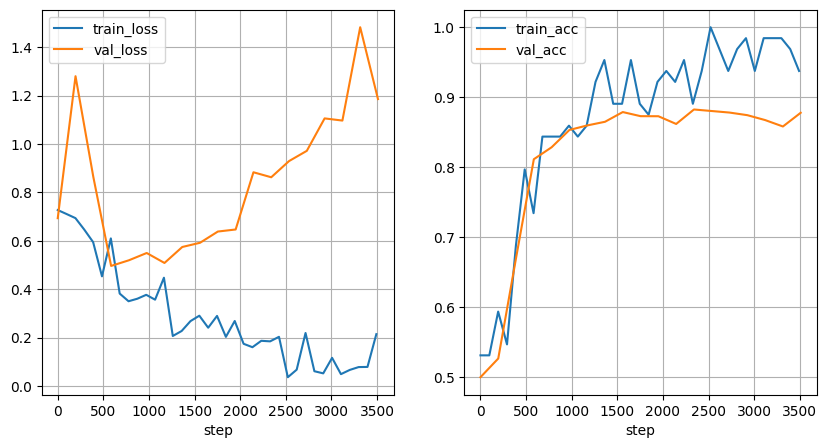

In [210]:
# 注意：损失并不是一定会降到 1 之内的
def plot_learning_curves(record_dict, sample_step=500):
    """
    绘制训练和验证的损失与准确率随训练步数变化的学习曲线。

    参数:
        record_dict (dict): 由 training() 返回的记录字典，包含 train 和 val 的历史指标
        sample_step (int): 训练曲线的降采样间隔（每隔多少条记录取一个点），
                           用于减少密集点数、使曲线更清晰，默认 500
    """
    # 将训练记录列表转为 DataFrame，以 step 为行索引，并每隔 sample_step 条取一个点（降采样）
    # 降采样原因：训练步数多时逐步绘制会过于密集，每隔 sample_step 取一点可保持曲线可读性
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]

    # 验证集记录通常每个 epoch 才有一条，无需降采样，直接转为 DataFrame
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")

    # 根据指标列数（loss 和 acc 共 2 列）动态创建子图
    fig_num = len(train_df.columns)  # 指标数量（通常为 2：loss 和 acc）

    # 创建 1 行 fig_num 列的子图网格，每个子图宽度为 5，高度为 5
    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))

    for idx, item in enumerate(train_df.columns):  # 遍历每个指标（loss、acc）
        # 在第 idx 个子图中绘制训练曲线（降采样后）
        axs[idx].plot(train_df.index, train_df[item], label=f"train_{item}")
        # 在同一子图中绘制验证曲线（每个 epoch 一个点）
        axs[idx].plot(val_df.index, val_df[item], label=f"val_{item}")
        axs[idx].grid()    # 添加网格线，便于读取数值
        axs[idx].legend()  # 显示图例（区分训练和验证曲线）
        axs[idx].set_xlabel("step")  # x 轴标签为全局训练步数

    plt.show()  # 渲染并显示图形
sample_step=eval_step//2
# 绘制学习曲线
plot_learning_curves(record, sample_step)

## 八、结果可视化

本节加载训练阶段保存的最优模型权重，在测试集上评估最终的分类损失和准确率，并绘制训练过程中的学习曲线。

In [211]:
# 加载测试集 DataLoader（供评估使用）
# 注：此处重新引用 test_dl，确保评估时使用与训练一致的数据处理流程

# 加载保存的最优模型权重文件（由 SaveCheckpointsCallback 保存的 best.ckpt）
# map_location="cpu"：将权重加载到 CPU，避免因训练/推理设备不一致导致的加载错误
model.load_state_dict(torch.load("model_checkpoints/5_model/5_model_best.ckpt", map_location="cpu"))

# 切换模型为评估模式，禁用 Dropout、BatchNorm 等训练专用行为
model.eval()

# 在测试集上计算损失和准确率
# evaluating() 函数内部使用 @torch.no_grad() 装饰器，不会计算梯度
loss, acc = evaluating(model, test_dl, loss_fct)

# 打印最终测试结果：损失保留 4 位小数，准确率保留 4 位小数
print(f"loss:     {loss:.4f}\naccuracy: {acc:.4f}")

loss:     0.8628
accuracy: 0.8825
